# Curve Bootstrapping

**Interactive Tutorial: Building Discount Curves from Market Instruments**

This notebook demonstrates:
1. Bootstrapping from deposits, FRAs, and swaps
2. Different interpolation methods
3. Forward rate calculation
4. Arbitrage validation

---

In [3]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# QuantStrata imports
import sys
sys.path.insert(0, '../..')  # Add project root to path

from src.marketdata.curves.bootstrapper import (
    DepositQuote,
    FraQuote,
    ParSwapQuote,
    bootstrap_discount_curve,
)
from src.marketdata.curves.interpolation import (
    create_curve_interpolator,
    simple_forward_rate_from_dfs,
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Discount Factors and Zero Rates

### 1.1 Key Definitions

**Discount Factor** $DF(T)$: Present value of \$1 received at time $T$
$$DF(T) = e^{-r(T) \cdot T}$$

**Zero Rate** $r(T)$: Continuously compounded rate
$$r(T) = -\frac{\ln(DF(T))}{T}$$

**Forward Rate** $f(T_1, T_2)$: Implied rate for period $(T_1, T_2)$
$$f(T_1, T_2) = -\frac{\ln(DF(T_2)/DF(T_1))}{T_2 - T_1}$$

In [4]:
# Example: DF and Zero Rate relationship
T = 1.0  # 1 year
r = 0.05  # 5% zero rate

# DF from zero rate
DF = np.exp(-r * T)
print(f"Given: Zero rate r = {r:.1%}, T = {T} year")
print(f"Discount Factor: DF(T) = exp(-r × T) = exp(-{r} × {T}) = {DF:.6f}")

# Zero rate from DF
r_back = -np.log(DF) / T
print(f"\nReverse: r(T) = -ln(DF)/T = -ln({DF:.6f})/{T} = {r_back:.4%}")

Given: Zero rate r = 5.0%, T = 1.0 year
Discount Factor: DF(T) = exp(-r × T) = exp(-0.05 × 1.0) = 0.951229

Reverse: r(T) = -ln(DF)/T = -ln(0.951229)/1.0 = 5.0000%


## 2. Bootstrapping from Deposits

### 2.1 Deposit Rate Formula

For a deposit with **simple compounding**:
$$DF(T) = \frac{1}{1 + r_{dep} \times T}$$

For **continuous compounding**:
$$DF(T) = e^{-r_{dep} \times T}$$

In [5]:
# Create deposit quotes
deposits = [
    DepositQuote(t=1/12, rate=0.02, label="1M", compounding="simple"),
    DepositQuote(t=3/12, rate=0.025, label="3M", compounding="simple"),
    DepositQuote(t=6/12, rate=0.028, label="6M", compounding="simple"),
]

print("Deposit Quotes:")
print(f"{'Label':>6} {'Tenor':>8} {'Rate':>8} {'DF':>10}")
print("-" * 35)

for dep in deposits:
    # Simple compounding DF
    df = 1 / (1 + dep.rate * dep.t)
    print(f"{dep.label:>6} {dep.t:>8.4f} {dep.rate:>8.2%} {df:>10.6f}")

Deposit Quotes:
 Label    Tenor     Rate         DF
-----------------------------------
    1M   0.0833    2.00%   0.998336
    3M   0.2500    2.50%   0.993789
    6M   0.5000    2.80%   0.986193


## 3. Bootstrapping from Swaps

### 3.1 Par Swap Equation

A **par swap** has NPV = 0 at inception:
$$\text{PV(Fixed Leg)} = \text{PV(Float Leg)}$$

$$R \sum_{i=1}^{n} \alpha_i \cdot DF(T_i) = 1 - DF(T_n)$$

**Solving for $DF(T_n)$:**
$$DF(T_n) = \frac{1 - R \sum_{i=1}^{n-1} \alpha_i \cdot DF(T_i)}{1 + R \cdot \alpha_n}$$

In [10]:
# Create swap quotes
swaps = [
    ParSwapQuote(kind="IRS", maturity_t=1.0, par_rate=0.030, fixed_freq="1Y", label="1Y"),
    ParSwapQuote(kind="IRS", maturity_t=2.0, par_rate=0.035, fixed_freq="1Y", label="2Y"),
    ParSwapQuote(kind="IRS", maturity_t=3.0, par_rate=0.038, fixed_freq="1Y", label="3Y"),
    ParSwapQuote(kind="IRS", maturity_t=4.0, par_rate=0.038, fixed_freq="1Y", label="4Y"),
    ParSwapQuote(kind="IRS", maturity_t=5.0, par_rate=0.042, fixed_freq="1Y", label="5Y"),
    ParSwapQuote(kind="IRS", maturity_t=6.0, par_rate=0.038, fixed_freq="1Y", label="6Y"),
    ParSwapQuote(kind="IRS", maturity_t=7.0, par_rate=0.038, fixed_freq="1Y", label="7Y"),
    ParSwapQuote(kind="IRS", maturity_t=8.0, par_rate=0.038, fixed_freq="1Y", label="8Y"),
    ParSwapQuote(kind="IRS", maturity_t=9.0, par_rate=0.038, fixed_freq="1Y", label="9Y"),
    ParSwapQuote(kind="IRS", maturity_t=10.0, par_rate=0.045, fixed_freq="1Y", label="10Y"),
]

print("Par Swap Quotes:")
print(f"{'Label':>6} {'Maturity':>10} {'Rate':>8}")
print("-" * 26)
for swap in swaps:
    print(f"{swap.label:>6} {swap.maturity_t:>10.1f}Y {swap.par_rate:>8.2%}")

Par Swap Quotes:
 Label   Maturity     Rate
--------------------------
    1Y        1.0Y    3.00%
    2Y        2.0Y    3.50%
    3Y        3.0Y    3.80%
    4Y        4.0Y    3.80%
    5Y        5.0Y    4.20%
    6Y        6.0Y    3.80%
    7Y        7.0Y    3.80%
    8Y        8.0Y    3.80%
    9Y        9.0Y    3.80%
   10Y       10.0Y    4.50%


## 4. Full Curve Bootstrap

### 4.1 Bootstrap Algorithm

In [11]:
# Combine all instruments
instruments = deposits + swaps

# Bootstrap the curve
result = bootstrap_discount_curve(
    instruments=instruments,
    engine="native",
    extrapolation="flat",
)

print("Bootstrapped Curve:")
print(f"{'Tenor':>8} {'DF':>12} {'Zero Rate':>12} {'Label':>8}")
print("-" * 45)

# Sort by tenor for display
sorted_instruments = sorted(instruments, key=lambda x: float(x.maturity))
for inst in sorted_instruments:
    t = float(inst.maturity)
    df = result.curve.df(t)
    zr = result.curve.zero_rate(t)
    label = getattr(inst, 'label', '')
    print(f"{t:>8.4f} {df:>12.6f} {zr:>12.2%} {label:>8}")

Bootstrapped Curve:
   Tenor           DF    Zero Rate    Label
---------------------------------------------
  0.0833     0.998336        2.00%       1M
  0.2500     0.993789        2.49%       3M
  0.5000     0.986193        2.78%       6M
  1.0000     0.970874        2.96%       1Y
  2.0000     0.933352        3.45%       2Y
  3.0000     0.893680        3.75%       3Y
  4.0000     0.860963        3.74%       4Y
  5.0000     0.812215        4.16%       5Y
  6.0000     0.799710        3.73%       6Y
  7.0000     0.770433        3.73%       7Y
  8.0000     0.742229        3.73%       8Y
  9.0000     0.715057        3.73%       9Y
 10.0000     0.634035        4.56%      10Y


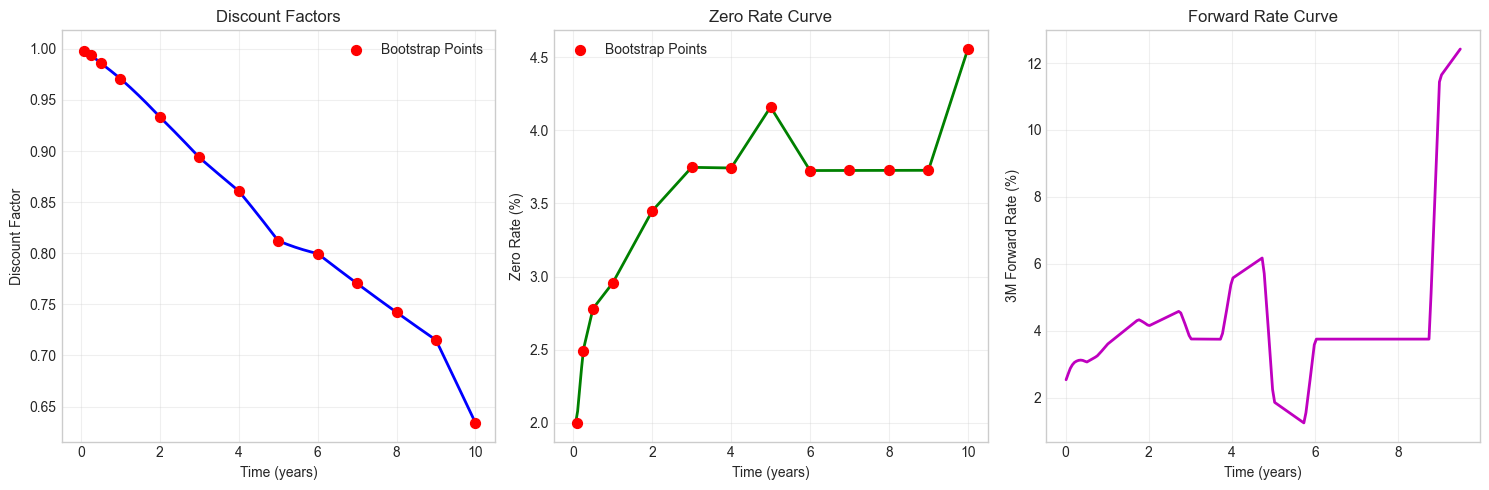

In [12]:
# Visualize the curve
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sample at fine grid
t_grid = np.linspace(0.01, 10, 200)
dfs = np.array([result.curve.df(t) for t in t_grid])
zrs = np.array([result.curve.zero_rate(t) for t in t_grid])

# Forward rates (3M forward)
fwds = []
for t in t_grid[:-10]:
    df1 = result.curve.df(t)
    df2 = result.curve.df(t + 0.25)
    fwd = simple_forward_rate_from_dfs(df1=df1, df2=df2, t1=t, t2=t+0.25)
    fwds.append(fwd)
fwds = np.array(fwds)

# Plot 1: Discount Factors
ax = axes[0]
ax.plot(t_grid, dfs, 'b-', linewidth=2)
ax.scatter(result.tenors, result.dfs, color='red', s=50, zorder=5, label='Bootstrap Points')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Discount Factor')
ax.set_title('Discount Factors')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Zero Rates
ax = axes[1]
ax.plot(t_grid, zrs * 100, 'g-', linewidth=2)
ax.scatter(result.tenors, result.zero_rates * 100, color='red', s=50, zorder=5, label='Bootstrap Points')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Zero Rate (%)')
ax.set_title('Zero Rate Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Forward Rates
ax = axes[2]
ax.plot(t_grid[:-10], fwds * 100, 'm-', linewidth=2)
ax.set_xlabel('Time (years)')
ax.set_ylabel('3M Forward Rate (%)')
ax.set_title('Forward Rate Curve')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Interpolation Methods

### 5.1 Comparing Different Methods

In [13]:
# Extract bootstrap points
tenors = result.tenors
dfs = result.dfs
zrs = result.zero_rates

# Create different interpolators
interp_linear_df = create_curve_interpolator(
    tenors=tenors, values=dfs, method="linear_df", value_type="df"
)
interp_log_linear = create_curve_interpolator(
    tenors=tenors, values=dfs, method="log_linear_df", value_type="df"
)
interp_linear_zr = create_curve_interpolator(
    tenors=tenors, values=zrs, method="linear_zero", value_type="zero_rate"
)
interp_spline_zr = create_curve_interpolator(
    tenors=tenors, values=zrs, method="cubic_spline_zero", value_type="zero_rate"
)

# Sample at fine grid
t_fine = np.linspace(tenors[0], tenors[-1], 200)

# Get DFs from each method
dfs_linear = np.array([float(interp_linear_df(t)) for t in t_fine])
dfs_loglin = np.array([float(interp_log_linear(t)) for t in t_fine])

# Get zero rates from zero rate interpolators
zrs_linear = np.array([float(interp_linear_zr(t)) for t in t_fine])
zrs_spline = np.array([float(interp_spline_zr(t)) for t in t_fine])

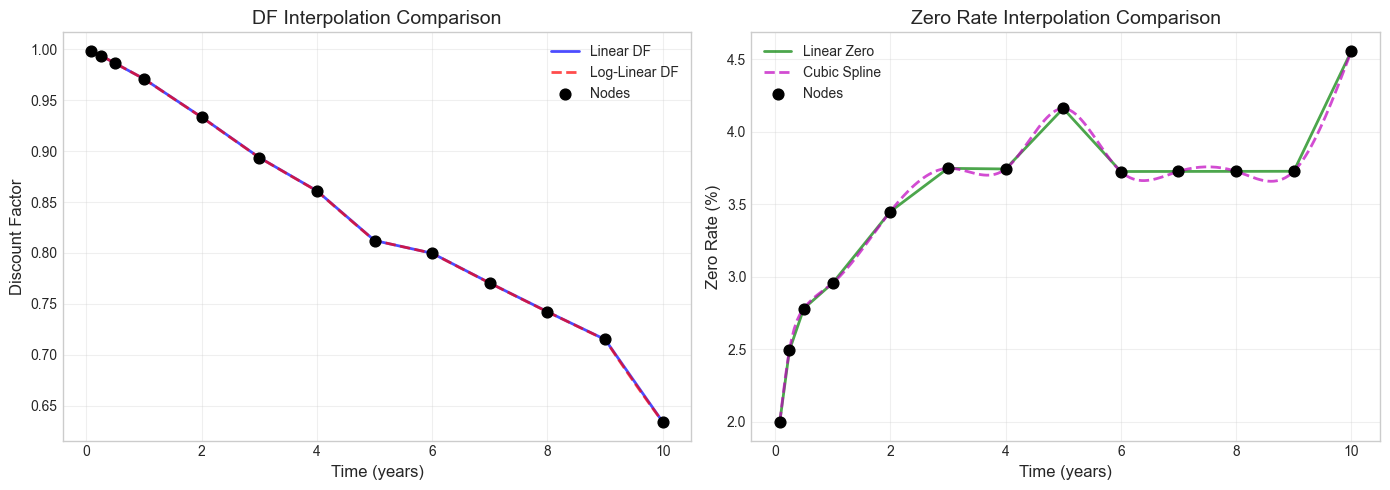

In [14]:
# Compare methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Discount Factors
ax = axes[0]
ax.plot(t_fine, dfs_linear, 'b-', linewidth=2, label='Linear DF', alpha=0.7)
ax.plot(t_fine, dfs_loglin, 'r--', linewidth=2, label='Log-Linear DF', alpha=0.7)
ax.scatter(tenors, dfs, color='black', s=60, zorder=5, label='Nodes')
ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Discount Factor', fontsize=12)
ax.set_title('DF Interpolation Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Zero Rates
ax = axes[1]
ax.plot(t_fine, zrs_linear * 100, 'g-', linewidth=2, label='Linear Zero', alpha=0.7)
ax.plot(t_fine, zrs_spline * 100, 'm--', linewidth=2, label='Cubic Spline', alpha=0.7)
ax.scatter(tenors, zrs * 100, color='black', s=60, zorder=5, label='Nodes')
ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Zero Rate (%)', fontsize=12)
ax.set_title('Zero Rate Interpolation Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Forward Rate Behavior

**Key Insight:** Log-linear interpolation in DFs produces **constant forward rates** between nodes.

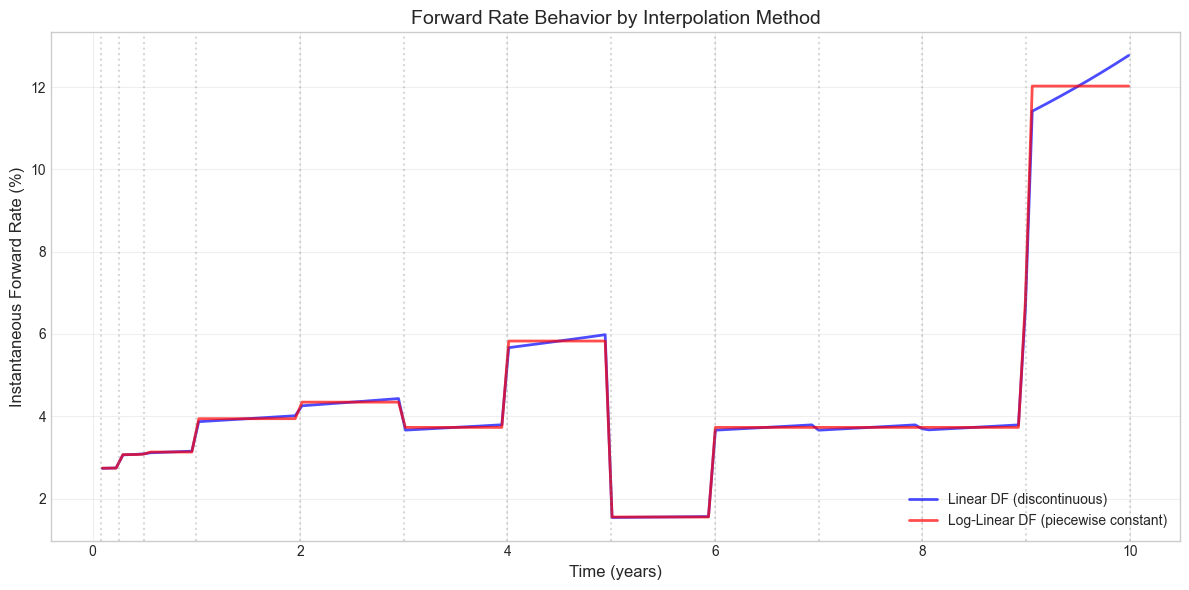

Note: Log-linear produces constant forward rates between nodes (jumps at nodes).
      Linear DF can produce discontinuous forward rates (numerically unstable).


In [15]:
# Compute forward rates for different methods
dt = 0.01  # Small time step for instantaneous forward
t_fwd = np.linspace(tenors[0] + dt, tenors[-1] - dt, 150)

def instant_forward(interp, t, dt=0.01):
    """Approximate instantaneous forward rate."""
    df1 = float(interp(t))
    df2 = float(interp(t + dt))
    return -np.log(df2 / df1) / dt

fwd_linear = np.array([instant_forward(interp_linear_df, t) for t in t_fwd])
fwd_loglin = np.array([instant_forward(interp_log_linear, t) for t in t_fwd])

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(t_fwd, fwd_linear * 100, 'b-', linewidth=2, label='Linear DF (discontinuous)', alpha=0.7)
ax.plot(t_fwd, fwd_loglin * 100, 'r-', linewidth=2, label='Log-Linear DF (piecewise constant)', alpha=0.7)

# Mark node positions
for t in tenors:
    ax.axvline(t, color='gray', linestyle=':', alpha=0.3)

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Instantaneous Forward Rate (%)', fontsize=12)
ax.set_title('Forward Rate Behavior by Interpolation Method', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Log-linear produces constant forward rates between nodes (jumps at nodes).")
print("      Linear DF can produce discontinuous forward rates (numerically unstable).")

## 6. Working with FRAs

### 6.1 Forward Rate Agreement

A FRA fixes a rate for a future period. The FRA rate is:
$$F_{t_1,t_2} = \frac{1}{t_2 - t_1}\left(\frac{DF(t_1)}{DF(t_2)} - 1\right)$$

In [16]:
# Create FRA quotes
fra_1x4 = FraQuote(t_start=1/12, t_end=4/12, forward_rate=0.026, label="1x4")
fra_3x6 = FraQuote(t_start=3/12, t_end=6/12, forward_rate=0.029, label="3x6")
fra_6x9 = FraQuote(t_start=6/12, t_end=9/12, forward_rate=0.031, label="6x9")

print("FRA Quotes:")
print(f"{'FRA':>6} {'Start':>8} {'End':>8} {'Rate':>8}")
print("-" * 33)
for fra in [fra_1x4, fra_3x6, fra_6x9]:
    print(f"{fra.label:>6} {fra.t_start:>8.4f} {fra.t_end:>8.4f} {fra.forward_rate:>8.2%}")

FRA Quotes:
   FRA    Start      End     Rate
---------------------------------
   1x4   0.0833   0.3333    2.60%
   3x6   0.2500   0.5000    2.90%
   6x9   0.5000   0.7500    3.10%


In [17]:
# Check implied forwards from our curve
print("\nImplied Forward Rates from Bootstrapped Curve:")
print(f"{'Period':>10} {'Market FRA':>12} {'Implied':>12} {'Diff (bp)':>12}")
print("-" * 50)

for fra in [fra_1x4, fra_3x6, fra_6x9]:
    df1 = result.curve.df(fra.t_start)
    df2 = result.curve.df(fra.t_end)
    implied_fwd = simple_forward_rate_from_dfs(df1=df1, df2=df2, t1=fra.t_start, t2=fra.t_end)
    diff_bp = (implied_fwd - fra.forward_rate) * 10000
    print(f"{fra.label:>10} {fra.forward_rate:>12.2%} {implied_fwd:>12.2%} {diff_bp:>12.1f}")


Implied Forward Rates from Bootstrapped Curve:
    Period   Market FRA      Implied    Diff (bp)
--------------------------------------------------
       1x4        2.60%        2.79%         19.5
       3x6        2.90%        3.08%         18.1
       6x9        3.10%        3.06%         -4.5


## 7. Arbitrage Validation

### 7.1 Key Conditions

1. **DFs must be positive**: $DF(T) > 0$
2. **DFs must decrease**: $DF(T_2) < DF(T_1)$ for $T_2 > T_1$
3. **Forward rates must be positive**: No free money!

In [18]:
def validate_curve(tenors, dfs):
    """Validate curve for arbitrage."""
    issues = []
    
    # Check DFs are positive
    if np.any(dfs <= 0):
        issues.append("FAIL: Non-positive discount factors detected")
    else:
        print("✓ All discount factors are positive")
    
    # Check DFs are decreasing
    if np.any(np.diff(dfs) >= 0):
        issues.append("FAIL: Discount factors not strictly decreasing")
    else:
        print("✓ Discount factors are strictly decreasing")
    
    # Check forward rates are positive
    for i in range(len(tenors) - 1):
        fwd = -np.log(dfs[i+1] / dfs[i]) / (tenors[i+1] - tenors[i])
        if fwd < 0:
            issues.append(f"FAIL: Negative forward rate at {tenors[i]:.2f} -> {tenors[i+1]:.2f}")
    
    if len(issues) == 0:
        print("✓ All forward rates are positive")
        print("\n*** Curve passes all arbitrage checks ***")
    else:
        for issue in issues:
            print(issue)
    
    return len(issues) == 0

# Validate our curve
print("Validating bootstrapped curve:")
print("-" * 40)
is_valid = validate_curve(result.tenors, result.dfs)

Validating bootstrapped curve:
----------------------------------------
✓ All discount factors are positive
✓ Discount factors are strictly decreasing
✓ All forward rates are positive

*** Curve passes all arbitrage checks ***


## 8. Summary and Key Takeaways

### Bootstrapping Process
1. **Short end**: Use deposits (simple compounding)
2. **Medium term**: Use FRAs to fill gaps
3. **Long end**: Use par swaps (iterative solution)

### Interpolation Methods
| Method | Forward Rates | Use Case |
|--------|---------------|----------|
| Log-linear DF | Piecewise constant | Industry standard |
| Linear zero | Continuous | Simple analysis |
| Cubic spline | Very smooth | Beware of arbitrage! |

### Interview Tips
1. **Know the par swap equation** and why PV(float) = 1 - DF(Tn)
2. **Understand interpolation trade-offs** (smoothness vs arbitrage)
3. **Be able to bootstrap by hand** for simple cases
4. **Know day count conventions** (ACT/360 for LIBOR, etc.)